In [1]:
# Bibliotecas usadas no notebook inteiro:
# pandas -> manipular tabelas (DataFrames)
# matplotlib / seaborn -> gráficos
# csr_matrix -> matriz esparsa (guarda só os valores que existem, economiza memória)
# TruncatedSVD -> versão do PCA que funciona direto com matriz esparsa
# numpy -> operações numéricas
# NearestNeighbors -> acha os itens mais parecidos sem calcular todas as distâncias de uma vez
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import numpy as np
from sklearn.neighbors import NearestNeighbors

In [2]:
# Carrega os dois arquivos do MovieLens: avaliações (ratings) e informações dos filmes (movies)
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

In [3]:
# Confere o tamanho dos dois datasets e dá uma olhada nas primeiras linhas de ratings
print(ratings.shape)
print(movies.shape)

ratings.head()

(32000204, 4)
(87585, 3)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [4]:
# Estatísticas básicas: quantas avaliações, quantos usuários e quantos filmes únicos existem
print("Número de avaliações:", len(ratings))
print("Número de usuários:", ratings["userId"].nunique())
print("Número de filmes:", ratings["movieId"].nunique())

ratings.describe()

Número de avaliações: 32000204
Número de usuários: 200948
Número de filmes: 84432


,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


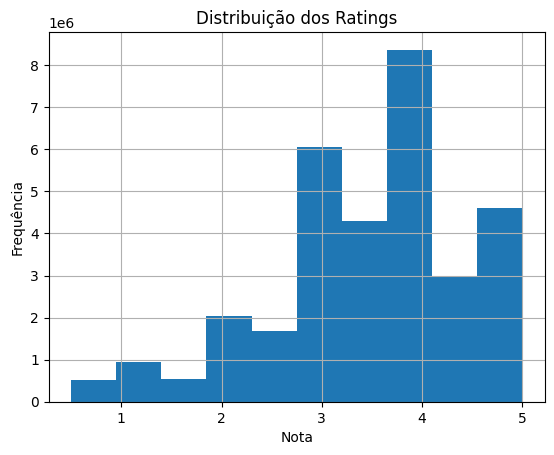

In [5]:
# Histograma das notas dadas pelos usuários, só para ver como elas se distribuem
ratings["rating"].hist(bins=10)

plt.title("Distribuição dos Ratings")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

In [6]:
# Filmes e usuários com mais avaliações (vai servir mais na frente para montar amostras)
top_movies = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

top_users = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

In [7]:
# Remove filmes com menos de 10 avaliações.
# Motivo: filme com poucas notas não dá pra calcular similaridade confiável, só atrapalha (ruído).
movie_counts = ratings.groupby("movieId").size()

valid_movies = movie_counts[
    movie_counts >= 10
].index

ratings_clean = ratings[
    ratings["movieId"].isin(valid_movies)
]

In [8]:
# Compara o tamanho antes/depois do filtro, só para ver quanto foi removido
print(ratings.shape)
print(ratings_clean.shape)

(32000204, 4)
(31842705, 4)


In [9]:
# Salva o dataset já limpo em disco (entregável da Semana 1)
ratings_clean.to_csv(
    "ratings_clean.csv",
    index=False
)

In [10]:
# Monta a matriz usuário x filme.
# Usamos matriz ESPARSA (csr_matrix) em vez de uma tabela normal (pivot_table), porque
# a matriz completa teria ~200 mil linhas x ~32 mil colunas - não caberia em memória
# se guardássemos também todas as células vazias.
# astype("category") transforma cada userId/movieId num código numérico sequencial
# (0, 1, 2...), que é o que csr_matrix precisa para saber a posição de cada avaliação.
user_ids = ratings_clean["userId"].astype("category")
movie_ids = ratings_clean["movieId"].astype("category")

X = csr_matrix(
    (
        ratings_clean["rating"],
        (
            user_ids.cat.codes,
            movie_ids.cat.codes
        )
    )
)

print(X.shape)

(200948, 31961)


In [11]:
# Sparsidade = % de células vazias na matriz. Esperado ser bem alto (>99%),
# já que cada usuário só avalia uma fração pequena de todos os filmes que existem.
sparsity = 1 - (X.nnz / (X.shape[0] * X.shape[1]))

print(f"Sparsidade: {sparsity:.4%}")

Sparsidade: 99.5042%


In [12]:
# Mesma ideia da célula anterior, só que em número absoluto de células vazias (missing)
total = X.shape[0] * X.shape[1]
missing = total - X.nnz

print("Missing:", missing)
print("Percentual:", 100 * missing / total)

Missing: 6390656323
Percentual: 99.50420070347732


In [13]:
# Média de nota de cada usuário (vai servir para normalizar as avaliações a seguir)
user_mean = (
    ratings_clean
    .groupby("userId")["rating"]
    .mean()
)

In [14]:
# Normalização: subtrai da nota de cada usuário a média dele mesmo.
# Motivo: um usuário exigente que dá nota 3 pra um filme que ele gostou não deveria
# ser tratado igual a alguém que dá nota 3 pra um filme que odiou.
# Depois dessa conta, nota positiva = "gostou mais que a média dele", negativa = "gostou menos".
ratings_norm = ratings_clean.copy()

ratings_norm["rating"] = (
    ratings_norm["rating"]
    - ratings_norm["userId"].map(user_mean)
)

In [15]:
# Reconstrói a matriz esparsa, agora com as notas já normalizadas (X_norm).
# É essa matriz normalizada que alimenta o PCA/SVD mais na frente.
X_norm = csr_matrix(
    (
        ratings_norm["rating"],
        (
            user_ids.cat.codes,
            movie_ids.cat.codes
        )
    )
)

In [16]:
# Só para conferir visualmente como fica a matriz esparsa por dentro (linha, coluna, valor)
print(X_norm)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31842705 stored elements and shape (200948, 31961)>
  Coords	Values
  (0, 16)	0.46808510638297873
  (0, 24)	-2.5319148936170213
  (0, 28)	-1.5319148936170213
  (0, 29)	1.4680851063829787
  (0, 31)	1.4680851063829787
  (0, 33)	-1.5319148936170213
  (0, 35)	-2.5319148936170213
  (0, 79)	1.4680851063829787
  (0, 108)	-0.5319148936170213
  (0, 109)	1.4680851063829787
  (0, 159)	-2.5319148936170213
  (0, 164)	1.4680851063829787
  (0, 174)	0.46808510638297873
  (0, 220)	-0.5319148936170213
  (0, 229)	1.4680851063829787
  (0, 257)	1.4680851063829787
  (0, 298)	0.46808510638297873
  (0, 302)	1.4680851063829787
  (0, 303)	1.4680851063829787
  (0, 318)	0.46808510638297873
  (0, 340)	-2.5319148936170213
  (0, 351)	-1.5319148936170213
  (0, 522)	-0.5319148936170213
  (0, 536)	1.4680851063829787
  (0, 555)	1.4680851063829787
  :	:
  (200947, 11305)	0.9046610169491527
  (200947, 11307)	0.4046610169491527
  (200947, 11308)	-1.5953389830508

In [17]:
# PCA / redução de dimensionalidade.
# Usamos TruncatedSVD em vez do PCA do sklearn porque o PCA tradicional exige matriz
# DENSA (sem esparsidade), e a nossa matriz é grande demais para densificar sem estourar
# a memória. Como os dados já estão centralizados por usuário (célula 13), o TruncatedSVD
# aqui dá praticamente o mesmo resultado que um PCA de verdade.
#
# Ajustamos com 100 componentes de uma vez só, e reaproveitamos esse mesmo ajuste pra
# calcular a variância explicada por 10, 20, 50 ou 100 componentes - assim não
# precisamos rodar o SVD quatro vezes (o que seria bem mais lento).
MAX_K = 100

svd = TruncatedSVD(n_components=MAX_K, random_state=42)
svd.fit(X_norm)

variancia_acumulada = np.cumsum(svd.explained_variance_ratio_)

component_options = [10, 20, 50, 100]

variance_df = pd.DataFrame({
    "n_components": component_options,
    "variancia_explicada_acumulada": [variancia_acumulada[k - 1] for k in component_options]
})

variance_df

,n_components,variancia_explicada_acumulada
0,10,0.091154
1,20,0.120259
2,50,0.174331
3,100,0.232035


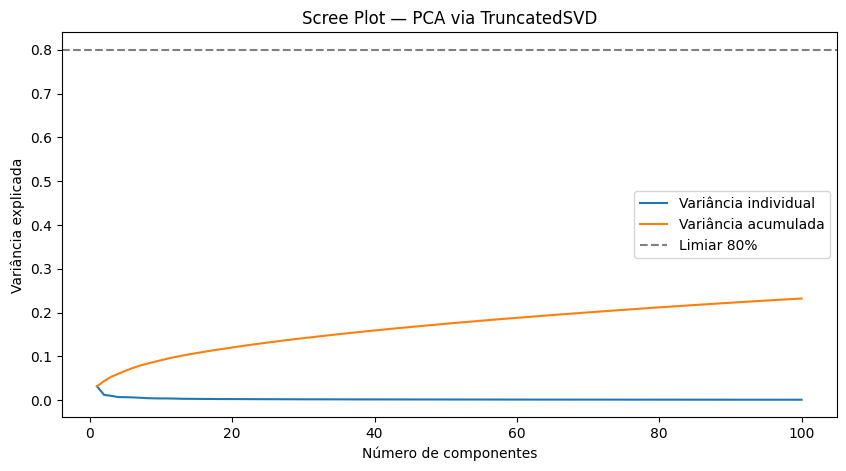

In [18]:
# Scree plot: mostra quanta variância cada componente explica (individual e acumulada).
# Serve pra decidir quantos componentes vale a pena manter - depois de um certo ponto,
# adicionar mais componentes quase não aumenta a variância explicada.
plt.figure(figsize=(10, 5))
plt.plot(range(1, MAX_K + 1), svd.explained_variance_ratio_, label="Variância individual")
plt.plot(range(1, MAX_K + 1), variancia_acumulada, label="Variância acumulada")
plt.axhline(0.8, color="gray", linestyle="--", label="Limiar 80%")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada")
plt.title("Scree Plot — PCA via TruncatedSVD")
plt.legend()
plt.savefig("scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Escolhemos 50 componentes (N_COMPONENTS) como tamanho final do espaço latente.
# user_factors: onde cada usuário "cai" nesse espaço latente.
# movie_loadings: onde cada filme "cai" nesse mesmo espaço - é isso que usamos
# pra calcular similaridade entre filmes daqui pra frente.
N_COMPONENTS = 50

user_factors = svd.transform(X_norm)[:, :N_COMPONENTS]
movie_loadings = svd.components_[:N_COMPONENTS].T

print("user_factors:", user_factors.shape)
print("movie_loadings:", movie_loadings.shape)

user_factors: (200948, 50)
movie_loadings: (31961, 50)


In [20]:
# Índice de vizinhos mais próximos (por cosseno) sobre os vetores latentes dos filmes.
# Por que não montar a matriz de similaridade inteira: com ~32 mil filmes, essa matriz
# ocuparia vários GB de memória. O NearestNeighbors guarda só os vetores e calcula
# as distâncias sob demanda, quando pedimos os vizinhos de um filme específico.
nn_pca = NearestNeighbors(metric="cosine")
nn_pca.fit(movie_loadings)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
# Tabela de referência: liga cada linha de movie_loadings (uma posição numérica)
# ao movieId e título reais do filme, respeitando a mesma ordem usada pela matriz.
movie_id_order = movie_ids.cat.categories  # movieId na mesma ordem das colunas de X_norm

movies_ordered = (
    movies[movies["movieId"].isin(movie_id_order)]
    .set_index("movieId")
    .loc[movie_id_order]
    .reset_index()
)

title_to_idx = pd.Series(movies_ordered.index, index=movies_ordered["title"])

print(movies_ordered.shape)
movies_ordered.head()

(31961, 3)


,index,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [22]:
# Pega a posição (índice numérico) dos 20 filmes mais avaliados, pra usar como
# amostra no heatmap de similaridade a seguir - mais fácil de visualizar do que
# tentar plotar os ~32 mil filmes de uma vez.
top_20_ids = top_movies.index  # já calculado na Etapa de EDA (Dia 2-3)
top_20_positions = [movie_id_order.get_loc(mid) for mid in top_20_ids if mid in movie_id_order]

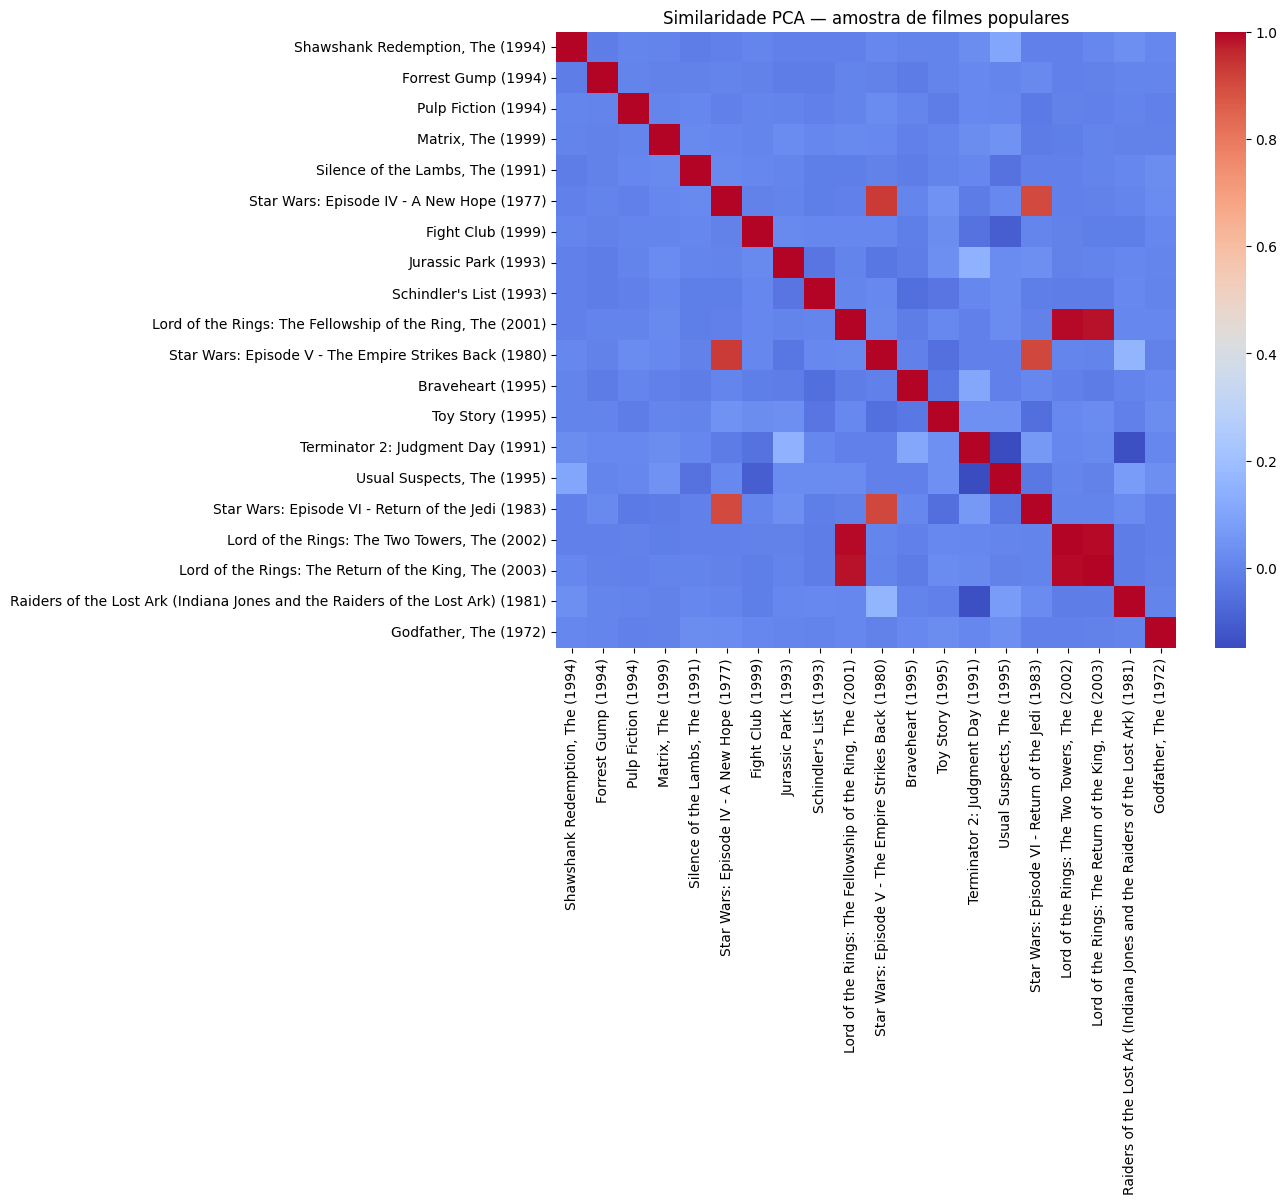

In [23]:
# Heatmap de similaridade PCA só para os 20 filmes mais populares.
# Aqui sim calculamos a matriz de similaridade completa, mas só para essa amostra
# pequena - para todos os filmes seria inviável em memória (ver célula 19).
from sklearn.metrics.pairwise import cosine_similarity

sim_sample = cosine_similarity(movie_loadings[top_20_positions])
sample_titles = movies_ordered.loc[top_20_positions, "title"].values

plt.figure(figsize=(10, 8))
sns.heatmap(sim_sample, xticklabels=sample_titles, yticklabels=sample_titles, cmap="coolwarm")
plt.title("Similaridade PCA — amostra de filmes populares")
plt.xticks(rotation=90)
plt.savefig("heatmap_similaridade_pca_amostra.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# Filtragem por conteúdo: transforma os gêneros de cada filme num vetor numérico (TF-IDF).
# Os gêneros vêm como string separada por "|" (ex: "Action|Adventure|Sci-Fi").
# Usamos um tokenizer que respeita o "|" como separador, em vez do tokenizer padrão do
# TfidfVectorizer, que quebraria "Sci-Fi" em "Sci" e "Fi" por causa do hífen.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=lambda s: s.split("|"), token_pattern=None)
genres_matrix = tfidf.fit_transform(movies_ordered["genres"])

print(genres_matrix.shape)
print("Gêneros encontrados:", tfidf.get_feature_names_out())

(31961, 20)
Gêneros encontrados: ['(no genres listed)' 'action' 'adventure' 'animation' 'children' 'comedy'
 'crime' 'documentary' 'drama' 'fantasy' 'film-noir' 'horror' 'imax'
 'musical' 'mystery' 'romance' 'sci-fi' 'thriller' 'war' 'western']


In [25]:
# Mesma lógica da célula 19, mas para os vetores de gênero (conteúdo) em vez dos latentes (PCA)
nn_content = NearestNeighbors(metric="cosine")
nn_content.fit(genres_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [26]:
# Funções de teste rápido: dado um filme, mostram os vizinhos mais próximos segundo
# o PCA e segundo o conteúdo (gêneros), separadamente. Serve pra comparar visualmente
# as duas abordagens antes de combiná-las no score híbrido.
def vizinhos_pca(titulo, k=10):
    idx = title_to_idx[titulo]
    dist, ind = nn_pca.kneighbors(movie_loadings[idx].reshape(1, -1), n_neighbors=k + 1)
    vizinhos = movies_ordered.iloc[ind[0][1:]]["title"].values  # [1:] pula o próprio filme
    return list(zip(vizinhos, 1 - dist[0][1:]))  # 1 - distância = similaridade de cosseno

def vizinhos_content(titulo, k=10):
    idx = title_to_idx[titulo]
    dist, ind = nn_content.kneighbors(genres_matrix[idx], n_neighbors=k + 1)
    vizinhos = movies_ordered.iloc[ind[0][1:]]["title"].values
    return list(zip(vizinhos, 1 - dist[0][1:]))

filme_teste = movies_ordered["title"].iloc[0]
print("Filme teste:", filme_teste)
print("\nVizinhos por PCA:")
for t, s in vizinhos_pca(filme_teste):
    print(f"  {t}  (sim={s:.3f})")
print("\nVizinhos por conteúdo (gêneros):")
for t, s in vizinhos_content(filme_teste):
    print(f"  {t}  (sim={s:.3f})")

Filme teste: Toy Story (1995)

Vizinhos por PCA:
  Toy Story 2 (1999)  (sim=0.875)
  Toy Story 3 (2010)  (sim=0.650)
  Bug's Life, A (1998)  (sim=0.577)
  Wallace & Gromit: A Close Shave (1995)  (sim=0.495)
  District, The (Nyócker!) (2004)  (sim=0.493)
  Wallace & Gromit: The Best of Aardman Animation (1996)  (sim=0.476)
  Wallace & Gromit: The Wrong Trousers (1993)  (sim=0.473)
  Halo: The Fall of Reach (2015)  (sim=0.466)
  Grand Day Out with Wallace and Gromit, A (1989)  (sim=0.465)
  Jack the Giant Killer (2013)  (sim=0.452)

Vizinhos por conteúdo (gêneros):
  The SpongeBob Movie: Sponge on the Run (2020)  (sim=1.000)
  Frozen II (2019)  (sim=1.000)
  Toy Story Toons: Small Fry (2011)  (sim=1.000)
  The Super Mario Bros. Movie (2023)  (sim=1.000)
  Brother Bear 2 (2006)  (sim=1.000)
  Hotel Transylvania: Transformania (2022)  (sim=1.000)
  Olaf's Frozen Adventure (2017)  (sim=1.000)
  Moana (2016)  (sim=1.000)
  Toy Story Toons: Hawaiian Vacation (2011)  (sim=1.000)
  Tangled: Bef

In [27]:
# IMPORTANTE: holdout (treino/teste) precisa ser feito ANTES de treinar o modelo de verdade.
# Se avaliarmos o modelo com dados que ele já viu no treino, o resultado da avaliação
# não vale nada (vazamento de dados / data leakage). Por isso, a partir daqui,
# refazemos o PCA e o TF-IDF usando só ratings_train.
from sklearn.model_selection import train_test_split

ratings_train, ratings_test = train_test_split(
    ratings_clean, test_size=0.2, random_state=42
)

# Remove do teste usuários/filmes que não aparecem no treino (evita cold start na avaliação)
usuarios_treino = set(ratings_train["userId"].unique())
filmes_treino = set(ratings_train["movieId"].unique())

ratings_test = ratings_test[
    ratings_test["userId"].isin(usuarios_treino)
    & ratings_test["movieId"].isin(filmes_treino)
]

print("ratings_train:", ratings_train.shape)
print("ratings_test :", ratings_test.shape)

ratings_train: (25474164, 4)
ratings_test : (6368541, 4)


In [28]:
# Reconstrução da matriz usuário x filme (Etapa 3), mas agora só com dados de treino.
# Repete a mesma lógica das células 9-14, trocando ratings_clean por ratings_train.
user_ids_train = ratings_train["userId"].astype("category")
movie_ids_train = ratings_train["movieId"].astype("category")

user_mean_train = ratings_train.groupby("userId")["rating"].mean()

ratings_train_norm = ratings_train.copy()
ratings_train_norm["rating"] = (
    ratings_train_norm["rating"] - ratings_train_norm["userId"].map(user_mean_train)
)

X_train_norm = csr_matrix(
    (
        ratings_train_norm["rating"],
        (user_ids_train.cat.codes, movie_ids_train.cat.codes),
    )
)

print(X_train_norm.shape)

(200948, 31961)


In [29]:
# Reconstrução do PCA/SVD (Etapa 4) e do TF-IDF (Etapa 5), agora só com dados de treino.
# Os nomes com sufixo "_train" daqui pra frente são os que valem pra avaliação (Precision@K);
# as versões sem sufixo (Semana 2) continuam existindo só pra explorar o catálogo completo.
svd_train = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors_train = svd_train.fit_transform(X_train_norm)
movie_loadings_train = svd_train.components_.T  # (n_filmes_treino, N_COMPONENTS)

movie_id_order_train = movie_ids_train.cat.categories
movies_ordered_train = (
    movies[movies["movieId"].isin(movie_id_order_train)]
    .set_index("movieId")
    .loc[movie_id_order_train]
)

# Garante que o índice mantém o nome 'movieId' antes de resetar o índice
movies_ordered_train.index.name = "movieId"
movies_ordered_train = movies_ordered_train.reset_index()

title_to_idx_train = pd.Series(movies_ordered_train.index, index=movies_ordered_train["title"])
movieid_to_pos_train = pd.Series(movies_ordered_train.index, index=movies_ordered_train["movieId"])

tfidf_train = TfidfVectorizer(tokenizer=lambda s: s.split("|"), token_pattern=None)
genres_matrix_train = tfidf_train.fit_transform(movies_ordered_train["genres"])

nn_pca_train = NearestNeighbors(metric="cosine")
nn_pca_train.fit(movie_loadings_train)

nn_content_train = NearestNeighbors(metric="cosine")
nn_content_train.fit(genres_matrix_train)

print("movie_loadings_train:", movie_loadings_train.shape)
print("genres_matrix_train :", genres_matrix_train.shape)

movie_loadings_train: (31961, 50)
genres_matrix_train : (31961, 20)


In [30]:
# Score híbrido = alpha * similaridade_PCA + beta * similaridade_conteúdo.
# Em vez de calcular a similaridade contra TODOS os filmes (caro demais em memória),
# pegamos só os candidatos que já apareceram como vizinhos próximos em uma das duas
# visões (PCA ou conteúdo) e calculamos a similaridade exata só pra esse grupo menor.
def _candidatos_hibridos(idx, alpha=0.6, beta=0.4, m_candidatos=50):
    """Retorna um DataFrame de candidatos (posição, sim_pca, sim_content, sim_hibrida)
    para o filme na posição `idx` do universo de treino."""
    _, ind_pca = nn_pca_train.kneighbors(
        movie_loadings_train[idx].reshape(1, -1), n_neighbors=m_candidatos + 1
    )
    _, ind_content = nn_content_train.kneighbors(
        genres_matrix_train[idx], n_neighbors=m_candidatos + 1
    )

    # Junta os candidatos das duas visões, sem repetir, e tira o próprio filme da lista
    candidatos = np.unique(np.concatenate([ind_pca[0], ind_content[0]]))
    candidatos = candidatos[candidatos != idx]

    sim_pca_vals = cosine_similarity(
        movie_loadings_train[idx].reshape(1, -1), movie_loadings_train[candidatos]
    )[0]
    sim_content_vals = cosine_similarity(
        genres_matrix_train[idx], genres_matrix_train[candidatos]
    )[0]

    sim_hibrida = alpha * sim_pca_vals + beta * sim_content_vals

    return pd.DataFrame({
        "pos": candidatos,
        "sim_pca": sim_pca_vals,
        "sim_content": sim_content_vals,
        "sim_hibrida": sim_hibrida,
    }).sort_values("sim_hibrida", ascending=False).reset_index(drop=True)


# Função principal: recebe um título e devolve os filmes mais parecidos, já ordenados
# pelo score híbrido, com os dois scores originais (PCA e conteúdo) também visíveis.
def recomendar(titulo, alpha=0.6, beta=0.4, top_n=10, m_candidatos=50):
    """Recomenda filmes similares a `titulo`, com os scores PCA/conteúdo decompostos."""
    idx = title_to_idx_train[titulo]
    candidatos_df = _candidatos_hibridos(idx, alpha, beta, m_candidatos).head(top_n)

    resultado = candidatos_df.copy()
    resultado["movieId"] = movies_ordered_train.loc[resultado["pos"], "movieId"].values
    resultado["title"] = movies_ordered_train.loc[resultado["pos"], "title"].values
    return resultado[["title", "sim_pca", "sim_content", "sim_hibrida"]]

In [31]:
# Dia 11-12 (entregável): testar recomendar() em 5 filmes escolhidos ao acaso
filmes_teste = movies_ordered_train["title"].sample(5, random_state=42).tolist()

for titulo in filmes_teste:
    print(f"\n=== Recomendações para: {titulo} ===")
    print(recomendar(titulo, top_n=5))


=== Recomendações para: Ace High (1968) ===
                                title   sim_pca  sim_content  sim_hibrida
0              Carry On Cowboy (1966)  0.721199     1.000000     0.832719
1              Sagebrush Trail (1933)  0.733735     0.920421     0.808410
2                    Boot Hill (1969)  0.584087     1.000000     0.750452
3  Wild Gals Of The Naked West (1962)  0.572330     1.000000     0.743398
4           Rustlers' Rhapsody (1985)  0.563996     1.000000     0.738398

=== Recomendações para: Kisses (2008) ===
                                               title   sim_pca  sim_content  \
0                        Shoeshine (Sciuscià) (1946)  0.913976          1.0   
1  Snows of Kilimanjaro, The (Neiges du Kilimandj...  0.894951          1.0   
2                                    Seashore (2015)  0.874025          1.0   
3  Record of a Tenement Gentleman (Nagaya shinshi...  0.862986          1.0   
4  Tale of Winter, A (a.k.a. A Winter's Tale) (Co...  0.861060          1

In [32]:
# Configuração da avaliação: qual nota conta como "positiva" (>= 4.0), quantas
# sementes usar por usuário, e quantos usuários avaliar (amostra, não todos os ~200 mil,
# porque avaliar todo mundo de uma vez seria muito lento).
LIMIAR_POSITIVO = 4.0
N_SEMENTES = 5
N_USUARIOS_AVALIACAO = 1000

rng = np.random.default_rng(42)
usuarios_avaliados = rng.choice(
    ratings_test["userId"].unique(),
    size=min(N_USUARIOS_AVALIACAO, ratings_test["userId"].nunique()),
    replace=False,
)

In [33]:
# Calcula Precision@5 e Precision@10 para UM usuário:
# 1. pega os filmes que o usuário avaliou bem no TREINO (sementes)
# 2. soma as recomendações híbridas de cada semente
# 3. compara o topo dessa lista com o que o usuário avaliou bem no TESTE
def avaliar_usuario(user_id, k_max=10, alpha=0.6, beta=0.4, m_candidatos=50, n_sementes=N_SEMENTES):
    hist_treino = ratings_train[ratings_train["userId"] == user_id]
    sementes = (
        hist_treino[hist_treino["rating"] >= LIMIAR_POSITIVO]
        .sort_values("rating", ascending=False)["movieId"]
        .head(n_sementes)
    )
    sementes_pos = [movieid_to_pos_train[m] for m in sementes if m in movieid_to_pos_train.index]
    if not sementes_pos:
        return None  # usuário sem filmes bem avaliados no treino -> não dá pra avaliar

    # Soma o score híbrido de cada candidato, juntando todas as sementes do usuário
    scores_acumulados = {}
    for idx in sementes_pos:
        candidatos_df = _candidatos_hibridos(idx, alpha, beta, m_candidatos)
        for pos, sim in zip(candidatos_df["pos"], candidatos_df["sim_hibrida"]):
            scores_acumulados[pos] = scores_acumulados.get(pos, 0.0) + sim

    # Tira as próprias sementes da lista (não faz sentido recomendar de volta o que já é semente)
    for pos in sementes_pos:
        scores_acumulados.pop(pos, None)
    if not scores_acumulados:
        return None

    top_pos = sorted(scores_acumulados, key=scores_acumulados.get, reverse=True)[:k_max]
    recomendados_ids = [movies_ordered_train.loc[p, "movieId"] for p in top_pos]

    # Filmes que o usuário realmente avaliou bem no conjunto de TESTE (nunca visto no treino)
    positivos_teste = set(
        ratings_test[
            (ratings_test["userId"] == user_id) & (ratings_test["rating"] >= LIMIAR_POSITIVO)
        ]["movieId"]
    )
    if not positivos_teste:
        return None  # usuário sem positivos no teste -> não dá pra medir acerto

    # Precision@K = quantos dos K recomendados realmente aparecem entre os positivos do teste
    p5 = len(set(recomendados_ids[:5]) & positivos_teste) / 5
    p10 = len(set(recomendados_ids[:10]) & positivos_teste) / min(10, len(recomendados_ids)) if recomendados_ids else 0.0
    return p5, p10

In [34]:
# Roda avaliar_usuario() para todos os usuários da amostra e junta os resultados numa tabela
resultados = []
for uid in usuarios_avaliados:
    r = avaliar_usuario(uid)
    if r is not None:
        resultados.append(r)

precisao_df = pd.DataFrame(resultados, columns=["P@5", "P@10"])
print("Usuários avaliados (com sementes e positivos no teste):", len(precisao_df))
precisao_df.mean()

Usuários avaliados (com sementes e positivos no teste): 978


P@5     0.045399
P@10    0.039059
dtype: float64

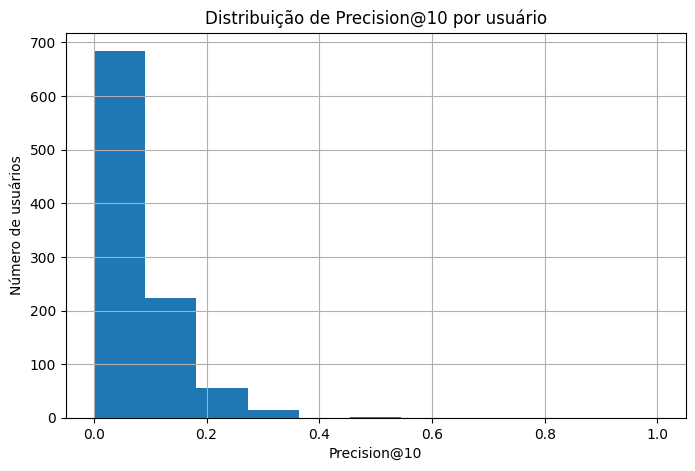

In [35]:
# histograma mostrando como a Precision@10 se distribui entre os usuários
plt.figure(figsize=(8, 5))
precisao_df["P@10"].hist(bins=11, range=(0, 1))
plt.title("Distribuição de Precision@10 por usuário")
plt.xlabel("Precision@10")
plt.ylabel("Número de usuários")
plt.savefig("distribuicao_precisao.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# Sensibilidade do alpha: testa alpha de 0.0 a 1.0 (de 0.1 em 0.1) e mede a Precision@10
# média em cada caso, pra ver qual proporção de PCA x conteúdo dá o melhor resultado.
# Usamos só 200 usuários aqui (menos que os 1000 da avaliação principal), porque esse
# laço roda a avaliação inteira 11 vezes (uma por valor de alpha).
alphas = np.round(np.arange(0.0, 1.01, 0.1), 1)
usuarios_sensibilidade = usuarios_avaliados[:200]  # subconjunto menor: 11 varreduras de alpha

precisao_por_alpha = []
for alpha in alphas:
    beta = round(1 - alpha, 1)
    p10s = []
    for uid in usuarios_sensibilidade:
        r = avaliar_usuario(uid, alpha=alpha, beta=beta)
        if r is not None:
            p10s.append(r[1])
    precisao_por_alpha.append(np.mean(p10s) if p10s else np.nan)

sensibilidade_df = pd.DataFrame({"alpha": alphas, "precisao_p10_media": precisao_por_alpha})
sensibilidade_df

,alpha,precisao_p10_media
0,0.0,0.017172
1,0.1,0.027273
2,0.2,0.027778
3,0.3,0.028788
4,0.4,0.032828
5,0.5,0.036364
6,0.6,0.037879
7,0.7,0.039899
8,0.8,0.042424
9,0.9,0.044444


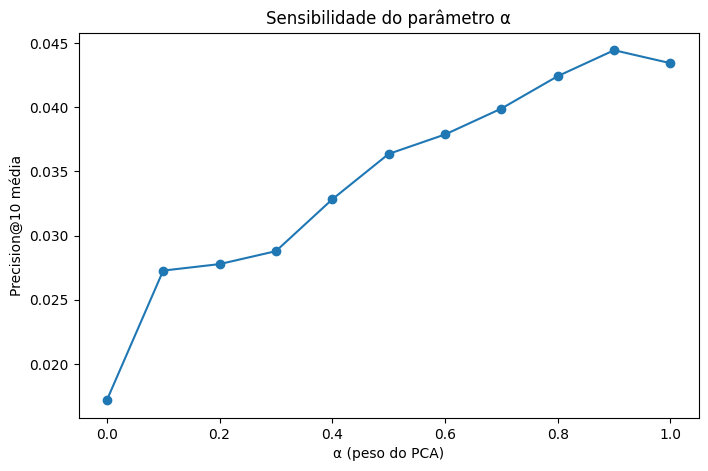

alpha ótimo encontrado: 0.9


In [37]:
# Gráfico da Precision@10 média em função do alpha, e identificação do melhor alpha encontrado
plt.figure(figsize=(8, 5))
plt.plot(sensibilidade_df["alpha"], sensibilidade_df["precisao_p10_media"], marker="o")
plt.xlabel("α (peso do PCA)")
plt.ylabel("Precision@10 média")
plt.title("Sensibilidade do parâmetro α")
plt.savefig("sensibilidade_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

alpha_otimo = sensibilidade_df.loc[sensibilidade_df["precisao_p10_media"].idxmax(), "alpha"]
print("alpha ótimo encontrado:", alpha_otimo)

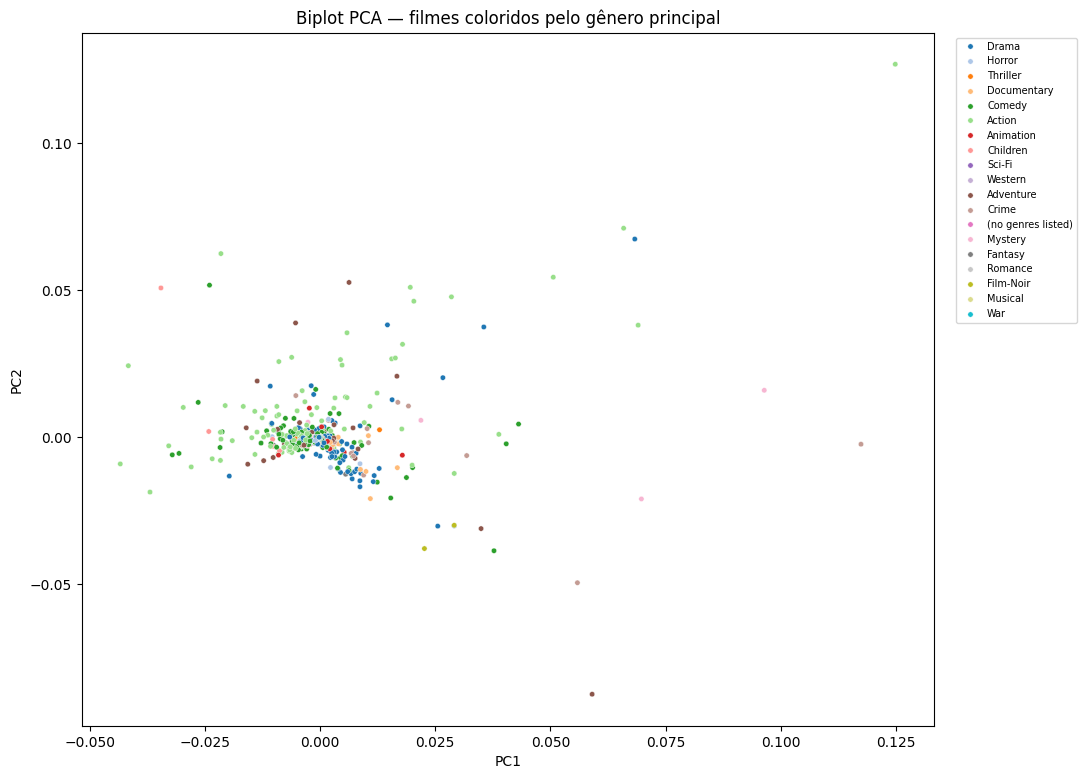

In [38]:
# Biplot: projeta uma amostra de 3000 filmes nos dois primeiros componentes do PCA (PC1 x PC2),
# colorindo pelo gênero principal de cada filme. Ajuda a ver se o espaço latente aprendeu
# alguma noção de gênero, ou se ele captura outro padrão (tipo popularidade).
# Usamos amostra porque plotar os ~32 mil filmes de uma vez ficaria ilegível.
N_AMOSTRA_BIPLOT = 3000
rng2 = np.random.default_rng(42)
amostra_pos = rng2.choice(movies_ordered_train.index, size=min(N_AMOSTRA_BIPLOT, len(movies_ordered_train)), replace=False)

genero_principal = movies_ordered_train["genres"].str.split("|").str[0]

plt.figure(figsize=(11, 9))
sns.scatterplot(
    x=movie_loadings_train[amostra_pos, 0],
    y=movie_loadings_train[amostra_pos, 1],
    hue=genero_principal.iloc[amostra_pos],
    palette="tab20",
    s=15,
    legend="brief",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA — filmes coloridos pelo gênero principal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.savefig("biplot_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Função auxiliar: busca filmes pelo título sem precisar saber o nome exato
# (útil porque recomendar() exige o título idêntico ao que está salvo na base)
def buscar_filme(termo):
    """Busca filmes que contêm o termo fornecido no título (case-insensitive)"""
    resultado = movies_ordered_train[
        movies_ordered_train["title"].str.contains(termo, case=False, na=False)
    ]
    if resultado.empty:
        return f"Nenhum filme encontrado com o termo: '{termo}'"
    return resultado[["title", "genres"]]
pd.set_option('display.max_colwidth', None)  # mostra o título inteiro, sem cortar

In [58]:
# Teste manual: procurando um filme específico pelo título parcial
buscar_filme("Alien")

,title,genres
1168,Aliens (1986),Action|Adventure|Horror|Sci-Fi
1181,Alien (1979),Horror|Sci-Fi
1284,Alien³ (a.k.a. Alien 3) (1992),Action|Horror|Sci-Fi|Thriller
1624,Alien: Resurrection (1997),Action|Horror|Sci-Fi
1625,Alien Escape (1995),Horror|Sci-Fi
3570,Alien Nation (1988),Crime|Drama|Sci-Fi|Thriller
4382,My Stepmother Is an Alien (1988),Comedy|Romance|Sci-Fi
4902,Italian for Beginners (Italiensk for begyndere) (2000),Comedy|Drama|Romance
5541,Without Warning (a.k.a. Alien Warning) (a.k.a. It Came Without Warning) (1980),Horror|Sci-Fi
6633,Alien Contamination (1980),Action|Horror|Sci-Fi


In [54]:
# Teste manual: pedindo recomendações para o filme encontrado acima
recomendar("I Travel Because I Have to, I Come Back Because I Love You (2009)", top_n=5)

,title,sim_pca,sim_content,sim_hibrida
0,"I Am Taraneh, I Am Fifteen Years Old (Man, taraneh, panzdah sal daram) (2002)",0.965534,1.0,0.979320
1,Jerusalem (1996),0.962196,1.0,0.977317
2,Violence at Noon (Hakuchu no torima) (1966),0.956984,1.0,0.974190
3,Intruder in the Dust (1949),0.948052,1.0,0.968831
4,"Silence, The (Sokout) (1998)",0.947286,1.0,0.968371
